In [1]:
import pandas as pd
from pathlib import Path
import wfdb
import matplotlib.pyplot as plt

BASE_PATH = Path.cwd().parent / 'data' / 'brugada-huca'

metadata = pd.read_csv(BASE_PATH / 'metadata.csv')

metadata

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1
...,...,...,...,...
358,3128957,0,0,0
359,3133602,0,0,0
360,3136075,0,0,0
361,3138453,0,0,0


In [2]:
brugadas = metadata.loc[metadata['brugada'] == 1, ['patient_id']]
healthies = metadata.loc[metadata['brugada'] == 0, ['patient_id']]

f'{len(brugadas)}, {len(healthies)}'

'69, 287'

In [3]:
brugadas = brugadas['patient_id'].to_numpy()
healthies = healthies['patient_id'].to_numpy()

In [4]:
import numpy as np 

# np.set_printoptions(threshold=np.inf)

Text(0.5, 0.98, 'Patient 489539')

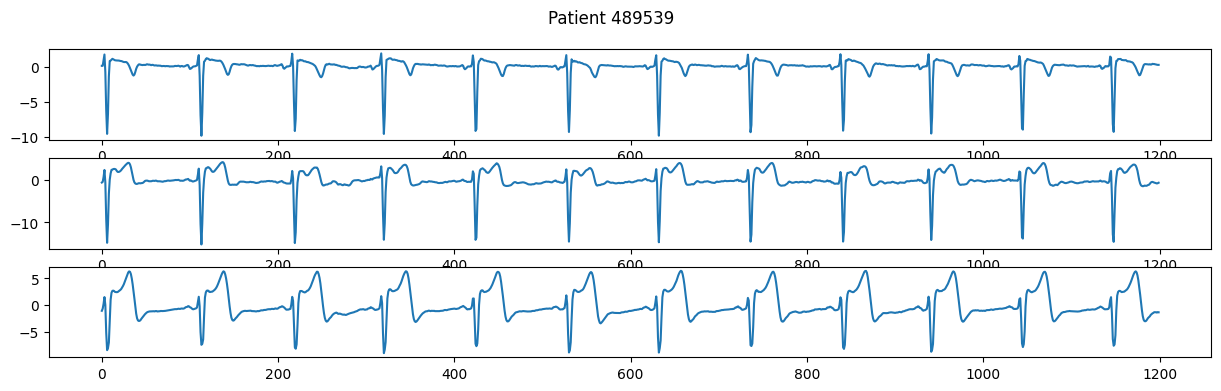

<Figure size 1200x400 with 0 Axes>

In [5]:
patient_id = '489539'
record = wfdb.rdrecord(BASE_PATH / f'files/{patient_id}/{patient_id}')

signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

fig, axs = plt.subplots(3, 1, figsize=(15, 4))
axs[0].plot(signals[:, 6]*10)
axs[1].plot(signals[:, 7]*10)
axs[2].plot(signals[:, 8]*10)
plt.figure(figsize=(12, 4))

fig.suptitle(f'Patient {patient_id}')
# plt.xlabel('Sample')
# plt.ylabel('Amplitude (mV)')
# plt.show()



# prompt = '''
# determine if this 100 Hz ECG in leads v1, v2, and v3 (measured in mm) has brugada patterns or not
# take note of possible 
# '''.strip()

# print(prompt)
# print('v1')
# print(signals[:, 6][:300] * 10)
# print('v2')
# print(signals[:, 7][:300] * 10)
# print('v3')
# print(signals[:, 8][:300] * 10)